In [1]:
from datascience import *
import numpy as np
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [3]:
patients = Table.read_table('breast-cancer.csv').drop('ID')
patients


Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
5,1,1,1,2,1,3,1,1,0
5,4,4,5,7,10,3,2,1,0
3,1,1,1,2,2,3,1,1,0
6,8,8,1,3,4,3,7,1,0
4,1,1,3,2,1,3,1,1,0
8,10,10,8,7,10,9,7,1,1
1,1,1,1,2,10,3,1,1,0
2,1,2,1,2,1,3,1,1,0
2,1,1,1,2,1,1,1,5,0
4,2,1,1,2,1,2,1,1,0


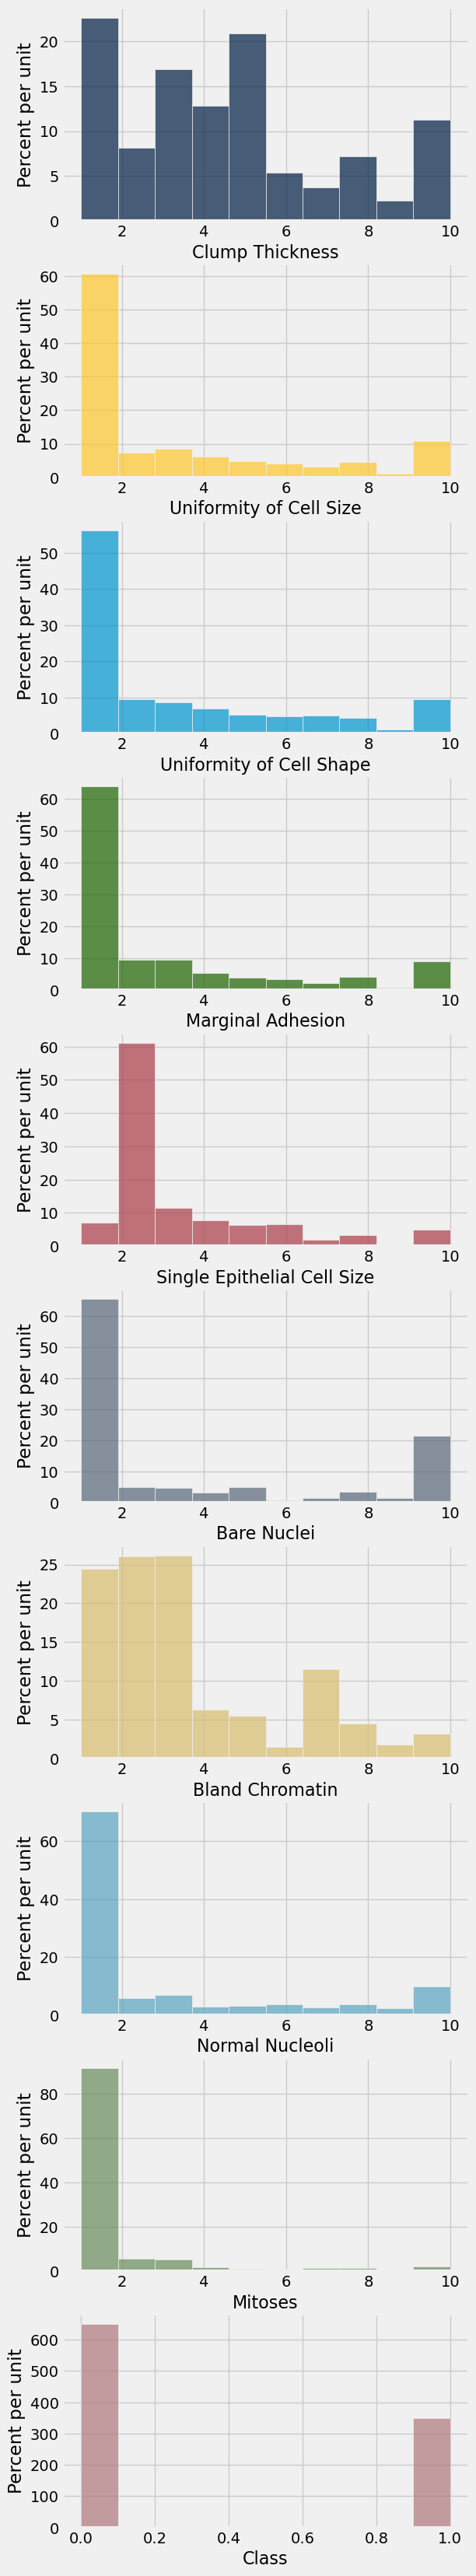

In [4]:
patients.hist(overlay=False)

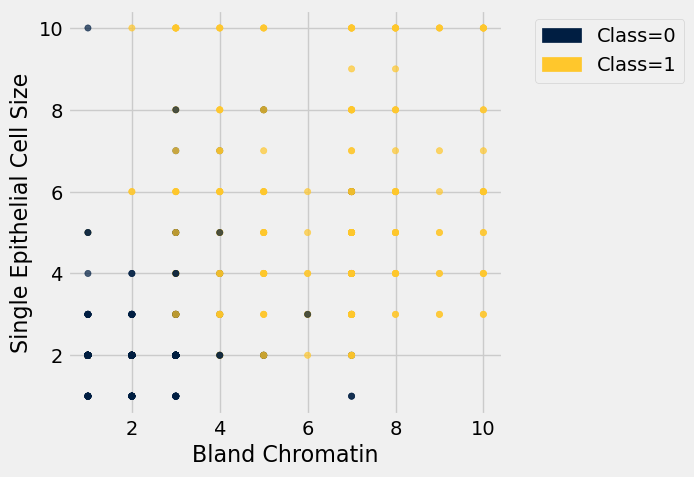

In [8]:
patients.scatter('Bland Chromatin', 'Single Epithelial Cell Size', group ='Class')

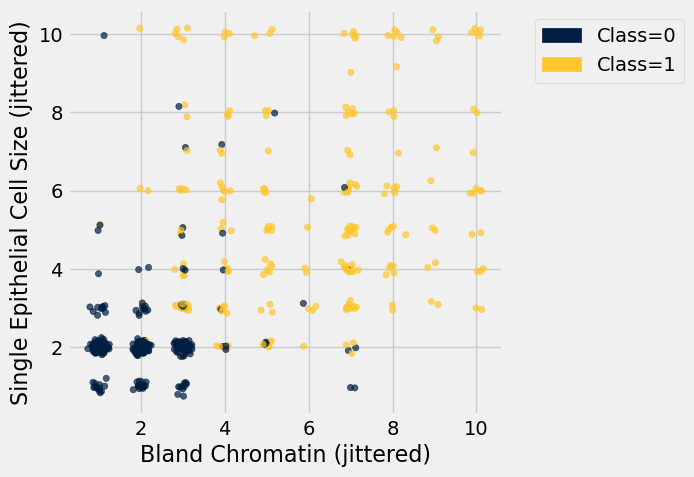

In [10]:
def randomize_column(a):
    return a + np.random.normal(0.0, 0.09, size=len(a))

jittered = Table().with_columns([
        'Bland Chromatin (jittered)', 
        randomize_column(patients.column('Bland Chromatin')),
        'Single Epithelial Cell Size (jittered)', 
        randomize_column(patients.column('Single Epithelial Cell Size')),
        'Class',
        patients.column('Class')
    ])

jittered.scatter(0, 1, 
                 group='Class')

## Distance ##

In [11]:
#The distance function returns the distance of two points 
#represented as arrays

def distance(pt1, pt2):
    return np.sqrt(sum((pt1-pt2)**2))

def row_distance(row1, row2):
    return distance(np.array(row1), np.array(row2))

In [12]:
row_distance([0,0], [3,4])

5.0

In [13]:
attributes = patients.drop('Class')
attributes.show(3)

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses
5,1,1,1,2,1,3,1,1
5,4,4,5,7,10,3,2,1
3,1,1,1,2,2,3,1,1


In [14]:
row_distance(attributes.row(0), attributes.row(1))

11.874342087037917

In [15]:
row_distance(attributes.row(10), attributes.row(14))

17.635192088548397

## Classification Procedure ##

In [25]:
def distances(training, example):
    """Compute distance between example and every row in training.
    Return training augmented with Distance column"""
    distances = make_array()
    attributes = training.drop('Class')
    for row in attributes.rows:
        distances = np.append(distances, row_distance(row, example))
    return training.with_column('Distance', distances)

In [26]:
example = attributes.row(20)
example
patients.take(20)

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
7,3,2,10,5,10,5,4,4,1


In [27]:
#Lets try the function
distances(patients.exclude(20), example).sort('Distance')

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class,Distance
7,5,3,7,4,10,7,5,5,1,4.58258
8,3,4,9,3,10,3,3,1,1,4.89898
10,3,3,10,2,10,7,3,3,1,5
10,4,4,10,2,10,5,3,3,1,5
10,4,4,10,6,10,5,5,1,1,5
5,3,2,8,5,10,8,1,2,1,5.47723
7,5,6,10,4,10,5,3,1,1,5.56776
8,7,5,10,7,9,5,5,4,1,5.65685
5,4,4,9,2,10,5,6,1,1,5.65685
6,5,5,8,4,10,3,4,1,1,5.65685


In [28]:
def closest(training, example, k):
    return distances(training, example).sort('Distance').take(np.arange(k))
    

In [29]:
closest(patients.exclude(20), example, 5)

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class,Distance
7,5,3,7,4,10,7,5,5,1,4.58258
8,3,4,9,3,10,3,3,1,1,4.89898
10,3,3,10,2,10,7,3,3,1,5
10,4,4,10,2,10,5,3,3,1,5
10,4,4,10,6,10,5,5,1,1,5


In [31]:
def majority_class(topk):
    """Return the class with the highest count"""
    return topk.group('Class').sort('count', descending=True).column(0).item(0)

def classify(training, example, k):
    "Return the majority class among the k nearest neighbors of example"
    return majority_class(closest(training, example, k))

In [33]:
classify(patients.exclude(20), example, 5)

1

In [43]:
patients.take(15)

Clump Thickness,Uniformity of Cell Size,Uniformity of Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Bland Chromatin,Normal Nucleoli,Mitoses,Class
7,4,6,4,6,1,4,3,1,1


In [44]:
classify(patients.exclude(15), example, 3)

1

## Evaluation ##

In [45]:
patients.num_rows

683

In [46]:
(0.5)*683

341.5

In [47]:
#Create training and test set
shuffled = patients.sample(with_replacement = False)
training_set = shuffled.take(np.arange(342))
test_set = shuffled.take(np.arange(342, 683))

In [48]:
#Return the proportion of correctly classified observations int he test data set
def evaluate_accuracy(training, test, k):
    test_attributes = test.drop('Class')
    num_correct = 0
    for i in np.arange(test.num_rows):
        c = classify(training, test_attributes.row(i), k)
        num_correct = num_correct + (c==test.column('Class').item(i))
    return num_correct/test.num_rows
   

In [49]:
evaluate_accuracy(training_set, test_set, 5)

0.9560117302052786

In [50]:
evaluate_accuracy(training_set, test_set, 3)

0.9560117302052786

In [51]:
evaluate_accuracy(training_set, test_set, 9)

0.9589442815249267

In [54]:
evaluate_accuracy(training_set,training_set , 1)

1.0